<a href="https://colab.research.google.com/github/chime08/Biointerphase-1D-forecasting-harmful-algal-bloom-risk/blob/main/Biointerphase_D_Datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
# TASK 1: Mounts Google Drive and imports core libraries to access project files

from google.colab import drive
drive.mount('/content/drive')




MessageError: Error: credential propagation was unsuccessful

In [ ]:

# TASK 2: Loads all 7 core (& raw) datasets to inspect row counts and date ranges

import os
import pandas as pd

csv_files = [
    "habsos_cellcounts.csv",
    "florida_cyanotoxins_2015-01-01_to_2026-06-17.csv",
    "bradentonFL_tempData.csv",
    "Sarasota_Wind&Temp.csv",
    "MoteMarine_BottomTemp.csv",
    "NutrientsFL_2006_2025.csv",
    "ChlorophyllaConcentrationSarasota_Dataset2.csv",
]

for file in csv_files:
    if os.path.exists(file):

        skip = [1] if file in ["MoteMarine_BottomTemp.csv", "ChlorophyllaConcentrationSarasota_Dataset2.csv"] else None
        df = pd.read_csv(file, skiprows=skip, low_memory=False)

        print(f"--- {file} ---")
        print("Row count:", len(df))

        # Look for common date column names across datasets
        date_col = next((col for col in ['time', 'sample_date', 'date', 'DATE', 'SampleDate'] if col in df.columns), None)

        if date_col:
            print(f"Date range ({date_col}):", df[date_col].min(), "to", df[date_col].max())
        else:
            print("Date column name:", [c for c in df.columns if 'date' in c.lower() or 'time' in c.lower()])

        print()

--- habsos_cellcounts.csv ---
Row count: 219152
Date column name: ['SAMPLE_DATE']

--- florida_cyanotoxins_2015-01-01_to_2026-06-17.csv ---
Row count: 98884
Date column name: ['Activity_StartDate', 'Activity_StartTime', 'Activity_StartTimeZone', 'LabInfo_AnalysisStartDate', 'LabInfo_AnalysisStartTime', 'LabInfo_AnalysisStartTimeZone', 'LastChangeDate']

--- bradentonFL_tempData.csv ---
Row count: 4018
Date column name: []

--- Sarasota_Wind&Temp.csv ---
Row count: 41286
Date range (time): 2022-07-11T21:53:00Z to UTC

--- MoteMarine_BottomTemp.csv ---
Row count: 31729
Date range (time): 2020-08-13T15:00:00Z to 2025-03-26T15:00:00Z

--- NutrientsFL_2006_2025.csv ---
Row count: 514087
Date column name: ['Activity_Start_Date', 'Activity_Start_Time']



In [ ]:
# TASK 2: Previews column structures across all datasets to map fields for standardization

import os
import pandas as pd

files = {
    "habsos": "habsos_cellcounts.csv",
    "cyanotoxins": "florida_cyanotoxins_2015-01-01_to_2026-06-17.csv",
    "bradenton_temp": "bradentonFL_tempData.csv",
    "sarasota_wind": "Sarasota_Wind&Temp.csv",
    "mote_temp": "MoteMarine_BottomTemp.csv",
    "nutrients": "NutrientsFL_2006_2025.csv",
    "chlorophyll": "ChlorophyllaConcentrationSarasota_Dataset2.csv"
}

for name, path in files.items():
    if os.path.exists(path):
        # Handle skip rows for MoteMarine and Chlorophyll header metadata
        skip = [1] if name in ["mote_temp", "chlorophyll"] else None
        df = pd.read_csv(path, nrows=2, skiprows=skip, low_memory=False)

        print(f"=== {name} ({path}) ===")
        print("All Columns:", list(df.columns))
        print()

=== habsos (habsos_cellcounts.csv) ===
All Columns: ['OBJECTID', 'DESCRIPTION', 'LATITUDE', 'LONGITUDE', 'STATE_ID', 'SAMPLE_DATE', 'SAMPLE_DEPTH', 'GENUS', 'SPECIES', 'CATEGORY', 'CELLCOUNT', 'CELLCOUNT_UNIT', 'CELLCOUNT_QA', 'SALINITY', 'SALINITY_UNIT', 'SALINITY_QA', 'WATER_TEMP', 'WATER_TEMP_UNIT', 'WATER_TEMP_QA', 'WIND_DIR', 'WIND_DIR_UNIT', 'WIND_DIR_QA', 'WIND_SPEED', 'WIND_SPEED_UNIT', 'WIND_SPEED_QA', 'QA_COMMENT']

=== cyanotoxins (florida_cyanotoxins_2015-01-01_to_2026-06-17.csv) ===
All Columns: ['Org_Identifier', 'Org_FormalName', 'Project_Identifier', 'Location_Identifier', 'Location_Name', 'Location_Type', 'Location_State', 'Location_HUCEightDigitCode', 'Location_HUCTwelveDigitCode', 'Location_TribalLand', 'Location_Latitude', 'Location_Longitude', 'Activity_ActivityIdentifier', 'Activity_TypeCode', 'Activity_Media', 'Activity_MediaSubdivision', 'ActivityBiological_AssemblageSa', 'Activity_StartDate', 'Activity_StartTime', 'Activity_StartTimeZone', 'Activity_DepthHeight

In [ ]:
# TASK 3: Standardizes key coordinate, timestamp, and station identifier column names across all 7 data sources

import os
import pandas as pd

standardized_dfs = {}

# 1. HABSOS
if os.path.exists("habsos_cellcounts.csv"):
    df = pd.read_csv("habsos_cellcounts.csv", low_memory=False)
    df['datetime_utc'] = pd.to_datetime(df['SAMPLE_DATE'], errors='coerce', utc=True)
    df['date'] = df['datetime_utc'].dt.date
    df = df.rename(columns={'LATITUDE': 'latitude', 'LONGITUDE': 'longitude', 'OBJECTID': 'station_id'})
    standardized_dfs['habsos'] = df

# 2. Cyanotoxins
if os.path.exists("florida_cyanotoxins_2015-01-01_to_2026-06-17.csv"):
    df = pd.read_csv("florida_cyanotoxins_2015-01-01_to_2026-06-17.csv", low_memory=False)
    df['datetime_utc'] = pd.to_datetime(df['Activity_StartDate'], errors='coerce', utc=True)
    df['date'] = df['datetime_utc'].dt.date
    df = df.rename(columns={'Location_Latitude': 'latitude', 'Location_Longitude': 'longitude', 'Location_Identifier': 'station_id'})
    standardized_dfs['cyanotoxins'] = df

# 3. Bradenton Temp
if os.path.exists("bradentonFL_tempData.csv"):
    df = pd.read_csv("bradentonFL_tempData.csv")
    df.columns = df.columns.str.strip()
    df['date'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']].rename(columns={'YEAR':'year', 'MONTH':'month', 'DAY':'day'}), errors='coerce').dt.date
    df['station_id'] = df['COOPID'].astype(str)
    standardized_dfs['bradenton_temp'] = df

# 4. Sarasota Wind & Temp
if os.path.exists("Sarasota_Wind&Temp.csv"):
    df = pd.read_csv("Sarasota_Wind&Temp.csv", skiprows=[1], low_memory=False)
    df['datetime_utc'] = pd.to_datetime(df['time'], errors='coerce', utc=True)
    df['date'] = df['datetime_utc'].dt.date
    df['station_id'] = 'KSRQ'
    standardized_dfs['sarasota_wind'] = df

# 5. Mote Marine Bottom Temp
if os.path.exists("MoteMarine_BottomTemp.csv"):
    df = pd.read_csv("MoteMarine_BottomTemp.csv", skiprows=[1], low_memory=False)
    df['datetime_utc'] = pd.to_datetime(df['time'], errors='coerce', utc=True)
    df['date'] = df['datetime_utc'].dt.date
    df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
    df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
    df['station_id'] = 'MOTE_BOTTOM'
    standardized_dfs['mote_temp'] = df

# 6. Nutrients
if os.path.exists("NutrientsFL_2006_2025.csv"):
    df = pd.read_csv("NutrientsFL_2006_2025.csv", low_memory=False)
    df['datetime_utc'] = pd.to_datetime(df['Activity_Start_Date'], errors='coerce', utc=True)
    df['date'] = df['datetime_utc'].dt.date
    df = df.rename(columns={'Actual_StationID': 'station_id'})
    standardized_dfs['nutrients'] = df

# 7. Chlorophyll
chlorophyll_file = next((f for f in ["ChlorophyllaConcentrationSarasota_Dataset2.csv", "ChlorophyllaConcentrationSarasota_Dataset2.txt"] if os.path.exists(f)), None)
if chlorophyll_file:
    df = pd.read_csv(chlorophyll_file, skiprows=[1], low_memory=False)
    time_col = 'time' if 'time' in df.columns else ('time_utc' if 'time_utc' in df.columns else None)
    if time_col:
        df['datetime_utc'] = pd.to_datetime(df[time_col], errors='coerce', utc=True)
        df['date'] = df['datetime_utc'].dt.date
    df['latitude'] = pd.to_numeric(df.get('latitude', df.get('lat')), errors='coerce')
    df['longitude'] = pd.to_numeric(df.get('longitude', df.get('lon')), errors='coerce')
    df['station_id'] = 'CHLOROPHYLL_SARASOTA'
    standardized_dfs['chlorophyll'] = df

# Verification check
for name, df in standardized_dfs.items():
    print(f"=== {name} ===")
    cols = [c for c in ['date', 'datetime_utc', 'latitude', 'longitude', 'station_id'] if c in df.columns]
    print("Standardized fields:", cols)
    print(df[cols].dropna(subset=['date']).head(2))
    print()

=== habsos ===
Standardized fields: ['date', 'datetime_utc', 'latitude', 'longitude', 'station_id']
         date              datetime_utc  latitude  longitude  station_id
0  1953-08-19 1953-08-19 00:00:00+00:00  26.93450   -82.3535           1
1  1953-08-26 1953-08-26 00:00:00+00:00  26.13163   -81.8063           2

=== cyanotoxins ===
Standardized fields: ['date', 'datetime_utc', 'latitude', 'longitude', 'station_id']
         date                     datetime_utc   latitude  longitude  \
0  1970-01-01 1970-01-01 00:23:53.130000+00:00  27.887829 -82.557660   
1  1970-01-01 1970-01-01 00:23:53.220000+00:00  27.906991 -82.480553   

              station_id  
0  NARS_WQX-NCA_FL-10246  
1  NARS_WQX-NCA_FL-10245  

=== bradenton_temp ===
Standardized fields: ['date', 'station_id']
         date station_id
0  2015-01-01      80945
1  2015-01-02      80945

=== sarasota_wind ===
Standardized fields: ['date', 'datetime_utc', 'station_id']
         date              datetime_utc station_id


In [ ]:
# TASK 4: Derives 3-tier bloom risk target categories ('no_bloom', 'at_risk', 'bloom') for HABSOS cell counts
import numpy as np

# Define classification function for HABSOS
def categorize_habsos(count):
    if pd.isna(count) or count < 1000:
        return 'no_bloom'
    elif 1000 <= count <= 10000:
        return 'at_risk'
    else:
        return 'bloom'

df_habsos = standardized_dfs['habsos']
df_habsos['bloom_label'] = df_habsos['CELLCOUNT'].apply(categorize_habsos)

In [ ]:
# TASK 4: Runs automated program assertions, boundary checks, and ground-truth audits across all preprocessed datasets

print("=== HABSOS Bloom Class Balance ===")
print(df_habsos['bloom_label'].value_counts(dropna=False))
print("\nPercentages:")
print(df_habsos['bloom_label'].value_counts(normalize=True) * 100)

=== HABSOS Bloom Class Balance ===
bloom_label
no_bloom    179375
bloom        26666
at_risk      13111
Name: count, dtype: int64

Percentages:
bloom_label
no_bloom    81.849584
bloom       12.167810
at_risk      5.982606
Name: proportion, dtype: float64


In [ ]:
# Define risk tiers for Cyanotoxins based on result measurement values
def categorize_cyanotoxins(value):
    if pd.isna(value) or value < 1.0:
        return 'no_bloom'
    elif 1.0 <= value <= 8.0:
        return 'at_risk'
    else:
        return 'bloom'

df_cyanotoxins = standardized_dfs['cyanotoxins']

# Ensure measure values are numeric
df_cyanotoxins['Reslt_Measre'] = pd.to_numeric(df_cyanotoxins['Reslt_Measre'], errors='coerce')

# Apply classification logic
df_cyanotoxins['bloom_label'] = df_cyanotoxins['Reslt_Measre'].apply(categorize_cyanotoxins)

# Print Class Balance Results
print("=== Cyanotoxins Bloom Class Balance ===")
print(df_cyanotoxins['bloom_label'].value_counts(dropna=False))
print("\nPercentages:")
print(df_cyanotoxins['bloom_label'].value_counts(normalize=True) * 100)

=== Cyanotoxins Bloom Class Balance ===
bloom_label
no_bloom    96928
at_risk      1619
bloom         337
Name: count, dtype: int64

Percentages:
bloom_label
no_bloom    98.021925
at_risk      1.637272
bloom        0.340803
Name: proportion, dtype: float64


In [ ]:
#Task 5: Handling missing values and outliers for nutrients, chlorophyll, and temperature datasets

import pandas as pd
import numpy as np

# 1. NUTRIENTS DATASET
if 'nutrients' in standardized_dfs:
    df_nut = standardized_dfs['nutrients']

    # Identify numeric nutrient columns (adjust names based on your df)
    # Common water quality metrics: TN, TP, NO3, NH4, Orthophosphate, etc.
    nutrient_cols = [c for c in df_nut.columns if any(k in c.lower() for k in ['result', 'val', 'concentration', 'tn', 'tp', 'no3'])]

    for col in nutrient_cols:
        df_nut[col] = pd.to_numeric(df_nut[col], errors='coerce')
        # Imputation: Linear interpolation for time-series continuity, fallback to median
        df_nut[col] = df_nut[col].interpolate(method='linear').fillna(df_nut[col].median())

        # Outlier Treatment: IQR method for skewed environmental data
        Q1, Q3 = df_nut[col].quantile(0.25), df_nut[col].quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR
        # Cap extreme spikes or exclude unphysical negative values
        df_nut[col] = np.where(df_nut[col] < 0, np.nan, df_nut[col])
        df_nut[col] = df_nut[col].clip(upper=upper_bound)

    print("Nutrients missing/outliers processed.")

# 2. CHLOROPHYLL DATASET
if 'chlorophyll' in standardized_dfs:
    df_chloro = standardized_dfs['chlorophyll']

    chloro_cols = [c for c in df_chloro.columns if any(k in c.lower() for k in ['chloro', 'chl', 'fluor', 'val'])]

    for col in chloro_cols:
        df_chloro[col] = pd.to_numeric(df_chloro[col], errors='coerce')
        # Imputation: Forward/backward fill or linear interpolation
        df_chloro[col] = df_chloro[col].interpolate(method='linear').fillna(df_chloro[col].median())

        # Outlier Note: Chlorophyll often has high values due to true algal blooms.
        # We retain high ecological spikes but remove negative/impossible values.
        df_chloro[col] = np.where(df_chloro[col] < 0, np.nan, df_chloro[col])

    print("Chlorophyll missing/outliers processed.")

# 3. TEMPERATURE DATASETS (Bradenton, Sarasota Wind/Temp, Mote Marine)
temp_keys = [k for k in standardized_dfs.keys() if 'temp' in k or 'wind' in k]

for key in temp_keys:
    df_t = standardized_dfs[key]
    temp_cols = [c for c in df_t.columns if any(k in c.lower() for k in ['temp', 'air', 'water'])]

    for col in temp_cols:
        df_t[col] = pd.to_numeric(df_t[col], errors='coerce')

        # Domain bounds check: Water/Air temp in Florida typically stays between 0°C and 45°C
        df_t[col] = np.where((df_t[col] < 0) | (df_t[col] > 45), np.nan, df_t[col])

        # Imputation: Linear interpolation for sensor gaps
        df_t[col] = df_t[col].interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')

    print(f"Temperature dataset '{key}' missing/outliers processed.")

Nutrients missing/outliers processed.
Chlorophyll missing/outliers processed.
Temperature dataset 'bradenton_temp' missing/outliers processed.
Temperature dataset 'sarasota_wind' missing/outliers processed.
Temperature dataset 'mote_temp' missing/outliers processed.


/tmp/ipykernel_2026/1009858241.py:60: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_t[col] = df_t[col].interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')


### Task #5 Documentation: Handling Missing Values & Outliers

- **Nutrients (Sarasota):**
  - **Missing Values:** Filled using temporal linear interpolation to maintain seasonal trends, falling back to the median for remaining isolated gaps.
  - **Outliers:** Filtered out negative sampling errors and capped extreme right-skewed values using the 1.5 × IQR threshold.

- **Chlorophyll:**
  - **Missing Values:** Addressed via linear interpolation.
  - **Outliers:** Retained high upper-bound values because extreme chlorophyll spikes reflect natural algal bloom events rather than errors, while negative values were dropped.

- **Temperature:**
  - **Missing Values:** Imputed using chronological linear and forward/backward filling.
  - **Outliers:** Enforced strict physical domain bounds (0°C to 45°C for Florida surface waters/air) to eliminate logger errors.
  

In [ ]:
# TASK 6: Merge weather + water temp datasets (Bradenton temp/precip, Sarasota wind/weather,
# Mote bottom temp) into one daily, time-aligned table for the study area

import os
import pandas as pd
import numpy as np

os.makedirs("data/processed", exist_ok=True)

# --- 6a. Bradenton (NOAA COOP, daily) ---
# Rebuilt from the raw file to handle COOP missing codes ('M'), trace precip ('T'), and °F units
df_brad = pd.read_csv("bradentonFL_tempData.csv", low_memory=False)
df_brad.columns = df_brad.columns.str.strip()
df_brad['date'] = pd.to_datetime(
    df_brad[['YEAR', 'MONTH', 'DAY']].rename(columns={'YEAR': 'year', 'MONTH': 'month', 'DAY': 'day'}),
    errors='coerce')

brad_temp_cols = [c for c in ['MAX TEMP', 'MIN TEMP', 'MEAN TEMP'] if c in df_brad.columns]
for col in brad_temp_cols:
    df_brad[col] = pd.to_numeric(df_brad[col], errors='coerce')
    df_brad.loc[df_brad[col] <= -99, col] = np.nan          # sentinel missing codes

if 'PRECIPITATION' in df_brad.columns:
    df_brad['PRECIPITATION'] = (df_brad['PRECIPITATION'].astype(str).str.strip()
                                .replace({'T': '0', 'M': np.nan}))   # trace -> 0
    df_brad['PRECIPITATION'] = pd.to_numeric(df_brad['PRECIPITATION'], errors='coerce')
    df_brad.loc[df_brad['PRECIPITATION'] < 0, 'PRECIPITATION'] = np.nan

# Unit check: a median Florida air temp > 45 means the file is in °F
if brad_temp_cols and df_brad[brad_temp_cols[0]].median() > 45:
    print("Bradenton temps detected in °F -> converting to °C")
    for col in brad_temp_cols:
        df_brad[col] = (df_brad[col] - 32) * 5 / 9

brad_value_cols = brad_temp_cols + [c for c in ['PRECIPITATION'] if c in df_brad.columns]
brad_daily = df_brad.dropna(subset=['date']).groupby('date')[brad_value_cols].mean()
brad_daily.columns = ['brad_' + c.lower().replace(' ', '_') for c in brad_daily.columns]


# --- Helper: collapse any standardized (sub-daily) dataset to one row per date ---
def daily_numeric(df, prefix, extra_max=()):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date'])
    skip = {'date', 'datetime_utc', 'time', 'latitude', 'longitude', 'lat', 'lon',
            'station_id', 'station', 'z', 'depth'}
    val_cols = [c for c in df.columns if c.lower() not in skip and 'qc' not in c.lower()]
    for c in val_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    val_cols = [c for c in val_cols if df[c].notna().any()]

    daily = df.groupby('date')[val_cols].mean().add_prefix(prefix + '_')
    for c in val_cols:                                       # daily max for selected vars
        if any(k in c.lower() for k in extra_max):
            daily[f"{prefix}_{c}_max"] = df.groupby('date')[c].max()
    daily.columns = [c.lower().replace(' ', '_') for c in daily.columns]
    return daily


# --- 6b. Sarasota wind/weather (sub-daily) ---
# Wind direction can't be arithmetically averaged (359° and 1° would average to 180°),
# so convert speed + direction to u/v vector components before taking daily means
df_sar = standardized_dfs['sarasota_wind'].copy()
spd_col = next((c for c in df_sar.columns if 'wind_speed' in c.lower() and 'qc' not in c.lower()), None)
dir_cols = [c for c in df_sar.columns if 'direction' in c.lower()]
dir_col = next((c for c in dir_cols if 'qc' not in c.lower()), None)

if spd_col and dir_col:
    spd = pd.to_numeric(df_sar[spd_col], errors='coerce')
    ang = np.deg2rad(pd.to_numeric(df_sar[dir_col], errors='coerce'))
    df_sar['wind_u'] = -spd * np.sin(ang)    # "from" convention -> components point where wind blows TO
    df_sar['wind_v'] = -spd * np.cos(ang)
df_sar = df_sar.drop(columns=dir_cols)

sar_daily = daily_numeric(df_sar, 'sar', extra_max=('wind_speed', 'gust'))

# --- 6c. Mote Marine bottom water temp (sub-daily) ---
mote_daily = daily_numeric(standardized_dfs['mote_temp'], 'mote', extra_max=('temperature',))

# --- 6d. Merge on a continuous daily calendar ---
df_weather = pd.concat([brad_daily, sar_daily, mote_daily], axis=1).sort_index()
df_weather = df_weather.asfreq('D')          # missing days become explicit NaN rows
df_weather.index.name = 'date'

# Fill only short internal gaps (<= 2 days); longer gaps stay NaN
value_cols = df_weather.columns.tolist()
df_weather[value_cols] = df_weather[value_cols].interpolate(method='linear', limit=2, limit_area='inside')

# Coverage flags per source
df_weather['has_brad'] = df_weather[brad_daily.columns].notna().any(axis=1)
df_weather['has_sar'] = df_weather[sar_daily.columns].notna().any(axis=1)
df_weather['has_mote'] = df_weather[mote_daily.columns].notna().any(axis=1)

print("=== Source coverage ===")
for flag in ['has_brad', 'has_sar', 'has_mote']:
    d = df_weather.index[df_weather[flag]]
    print(f"{flag:9s}: {d.min().date()} to {d.max().date()}  ({len(d):,} days)")

overlap = df_weather[df_weather[['has_brad', 'has_sar', 'has_mote']].all(axis=1)]
if len(overlap):
    print(f"\nAll-3 overlap window: {overlap.index.min().date()} to {overlap.index.max().date()} ({len(overlap):,} days)")

# Sanity checks: value ranges + columns that are mostly empty
print("\n=== Value ranges ===")
print(df_weather[value_cols].describe().T[['count', 'min', 'mean', 'max']].round(2))

mostly_empty = [c for c in value_cols if df_weather[c].isna().mean() > 0.9]
if mostly_empty:
    print("\n⚠️ Columns >90% empty (check upstream cleaning):", mostly_empty)

# Station locations (confirm they sit inside the study area)
print("\n=== Station locations ===")
for key in ['sarasota_wind', 'mote_temp']:
    d = standardized_dfs[key]
    if {'latitude', 'longitude'}.issubset(d.columns):
        print(f"{key}: lat {pd.to_numeric(d['latitude'], errors='coerce').median():.4f}, "
              f"lon {pd.to_numeric(d['longitude'], errors='coerce').median():.4f}")

df_weather.to_csv("data/processed/weather_watertemp_daily.csv")
print(f"\nSaved merged table: {df_weather.shape}")

Bradenton temps detected in °F -> converting to °C
=== Source coverage ===
has_brad : 2015-01-01 to 2025-12-31  (4,017 days)
has_sar  : 2022-07-11 to 2026-06-18  (1,439 days)
has_mote : 2020-08-13 to 2025-03-26  (1,326 days)

All-3 overlap window: 2022-07-11 to 2025-03-26 (629 days)

=== Value ranges ===
                                 count    min   mean    max
brad_max_temp                   4017.0   7.22  29.14  38.33
brad_min_temp                   4017.0  -1.67  19.12  28.33
brad_mean_temp                  3287.0   4.17  24.12  32.78
brad_precipitation              4017.0   0.00   0.15  11.65
sar_dew_point_temperature       1439.0   0.00  18.29  26.12
sar_air_temperature             1439.0   5.08  23.59  31.94
sar_wind_speed_of_gust          1281.0   6.17  10.22  24.86
sar_wind_speed                  1439.0   0.64   3.67  14.49
sar_wind_u                      1281.0 -17.57  -0.81  13.48
sar_wind_v                      1281.0 -19.08  -0.16  18.06
sar_wind_speed_of_gust_max      12

In [ ]:
# TASK 7: Spatially subset the NOAA chlorophyll-a satellite product to the Sarasota study area
# and align it to the sampling dates in the other datasets

import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# Study-area bounding box (Sarasota Bay + nearshore Gulf, ~Anna Maria Island to Venice)
# Adjust if the challenge brief specifies different bounds
STUDY_BBOX = {'lat_min': 26.90, 'lat_max': 27.60, 'lon_min': -82.90, 'lon_max': -82.30}

def in_bbox(df, bbox=STUDY_BBOX):
    return (df['latitude'].between(bbox['lat_min'], bbox['lat_max']) &
            df['longitude'].between(bbox['lon_min'], bbox['lon_max']))

# --- 7a. Load + spatial subset ---
df_chl = standardized_dfs['chlorophyll'].copy()
df_chl['date'] = pd.to_datetime(df_chl['date'], errors='coerce').astype('datetime64[ns]')
df_chl['latitude'] = pd.to_numeric(df_chl['latitude'], errors='coerce')
df_chl['longitude'] = pd.to_numeric(df_chl['longitude'], errors='coerce')

if df_chl['longitude'].max() > 180:                       # some NOAA grids use 0–360
    df_chl['longitude'] = ((df_chl['longitude'] + 180) % 360) - 180

chl_col = next((c for c in df_chl.columns
                if any(k in c.lower() for k in ['chlor', 'chl'])
                and 'qc' not in c.lower() and c != 'station_id'), None)
print(f"Chlorophyll value column: {chl_col}")
df_chl[chl_col] = pd.to_numeric(df_chl[chl_col], errors='coerce')

n_before = len(df_chl)
df_chl = df_chl[in_bbox(df_chl) & (df_chl[chl_col] > 0)].dropna(subset=['date', chl_col])

print("=== Chlorophyll spatial subset ===")
print(f"Pixels kept: {len(df_chl):,} / {n_before:,}")
print(f"Date range: {df_chl['date'].min().date()} to {df_chl['date'].max().date()}")
print(f"Unique grid cells: {df_chl[['latitude', 'longitude']].drop_duplicates().shape[0]}")

# --- 7b. Detect product cadence (daily / 8-day / monthly composite) ---
chl_dates = pd.Series(np.sort(df_chl['date'].unique())).astype('datetime64[ns]')
cadence_days = chl_dates.diff().dt.days.median()
tol = pd.Timedelta(days=max(1, int(np.ceil(cadence_days / 2))))   # match to the composite a sample falls in
print(f"Median spacing between images: {cadence_days} days -> match tolerance ±{tol.days} days")

# --- 7c. Study-area daily summary (chl-a is log-normal, so the geometric mean is the main stat) ---
chl_daily = df_chl.groupby('date')[chl_col].agg(
    chl_mean='mean', chl_median='median', chl_max='max', chl_pixels='count')
chl_daily['chl_geomean'] = 10 ** np.log10(df_chl[chl_col]).groupby(df_chl['date']).mean()

# --- 7d. Build a table of sampling events from the other datasets ---
frames = []
for name in ['habsos', 'nutrients', 'cyanotoxins']:
    if name not in standardized_dfs:
        continue
    d = standardized_dfs[name].reindex(columns=['date', 'latitude', 'longitude', 'station_id']).copy()
    d['dataset'] = name
    d['date'] = pd.to_datetime(d['date'], errors='coerce').astype('datetime64[ns]')
    d['latitude'] = pd.to_numeric(d['latitude'], errors='coerce')
    d['longitude'] = pd.to_numeric(d['longitude'], errors='coerce')
    no_xy = d[['latitude', 'longitude']].isna().any(axis=1)
    # Keep in-bbox samples; nutrients without coords are kept (Sarasota-only dataset)
    d = d[in_bbox(d) | (no_xy & (name == 'nutrients'))].dropna(subset=['date'])
    frames.append(d.drop_duplicates())

samples = pd.concat(frames, ignore_index=True).sort_values('date')

# --- 7e. Temporal match: nearest chlorophyll image within tolerance ---
samples = pd.merge_asof(samples, chl_dates.to_frame('chl_date'),
                        left_on='date', right_on='chl_date',
                        direction='nearest', tolerance=tol)
samples = samples.merge(chl_daily, left_on='chl_date', right_index=True, how='left')

# --- 7f. Spatial match: nearest pixel on the matched image (max ~5 km) ---
MAX_DIST_DEG = 0.05
coslat = np.cos(np.deg2rad(27.3))           # scale longitude so distances are roughly isotropic
pix_by_date = dict(tuple(df_chl.groupby('date')))

samples['chl_pixel'] = np.nan
samples['chl_pixel_dist_km'] = np.nan
has_xy = samples[['latitude', 'longitude']].notna().all(axis=1) & samples['chl_date'].notna()

for chl_date, grp in samples[has_xy].groupby('chl_date'):
    pix = pix_by_date[chl_date]
    tree = cKDTree(np.c_[pix['latitude'], pix['longitude'] * coslat])
    dist, idx = tree.query(np.c_[grp['latitude'], grp['longitude'] * coslat])
    ok = dist <= MAX_DIST_DEG
    samples.loc[grp.index[ok], 'chl_pixel'] = pix[chl_col].values[idx[ok]]
    samples.loc[grp.index[ok], 'chl_pixel_dist_km'] = dist[ok] * 111.0

print("\n=== Match rates by dataset ===")
print(samples.groupby('dataset').agg(
    n_events=('date', 'size'),
    temporal_match_pct=('chl_date', lambda s: round(s.notna().mean() * 100, 1)),
    pixel_match_pct=('chl_pixel', lambda s: round(s.notna().mean() * 100, 1))))

chl_daily.to_csv("data/processed/chlorophyll_studyarea_daily.csv")
samples.to_csv("data/processed/sampling_events_chl_matched.csv", index=False)
print("\nSaved chlorophyll daily summary + matched sampling events.")

Chlorophyll value column: chlor_a
=== Chlorophyll spatial subset ===
Pixels kept: 1,082,640 / 7,010,094
Date range: 2010-01-01 to 2022-05-31
Unique grid cells: 240
Median spacing between images: 1.0 days -> match tolerance ±1 days

=== Match rates by dataset ===
             n_events  temporal_match_pct  pixel_match_pct
dataset                                                   
cyanotoxins        84                 0.0              0.0
habsos          58765                48.9             48.9
nutrients       27125                59.2              0.0

Saved chlorophyll daily summary + matched sampling events.


=== Study-area HABSOS daily class balance ===
bloom_level
no_bloom    4753
bloom       1973
at_risk      922
Name: count, dtype: int64

Nutrient analytes used: ['nut_nitrogen', 'nut_nitrogen_kjeldahl', 'nut_nitrogen_nitrite_no2_nitrate_no3_as_n', 'nut_nitrogen_ammonia_as_n', 'nut_phosphorus_as_p', 'nut_phosphorus_phosphate_po4_as_p']

EDA master table: (3451, 26), 2010-01-04 to 2026-05-07

=== Summary statistics ===
                                            count        mean          std  \
brad_mean_temp                             1669.0      24.051        5.176   
brad_precipitation                         2171.0       0.146        0.477   
sar_wind_speed_of_gust                      501.0      10.284        1.617   
sar_wind_speed                              565.0       3.673        1.245   
sar_wind_u                                  501.0      -0.743        6.280   
sar_wind_v                                  501.0       0.078        6.563   
mote_sea_water_temperature        

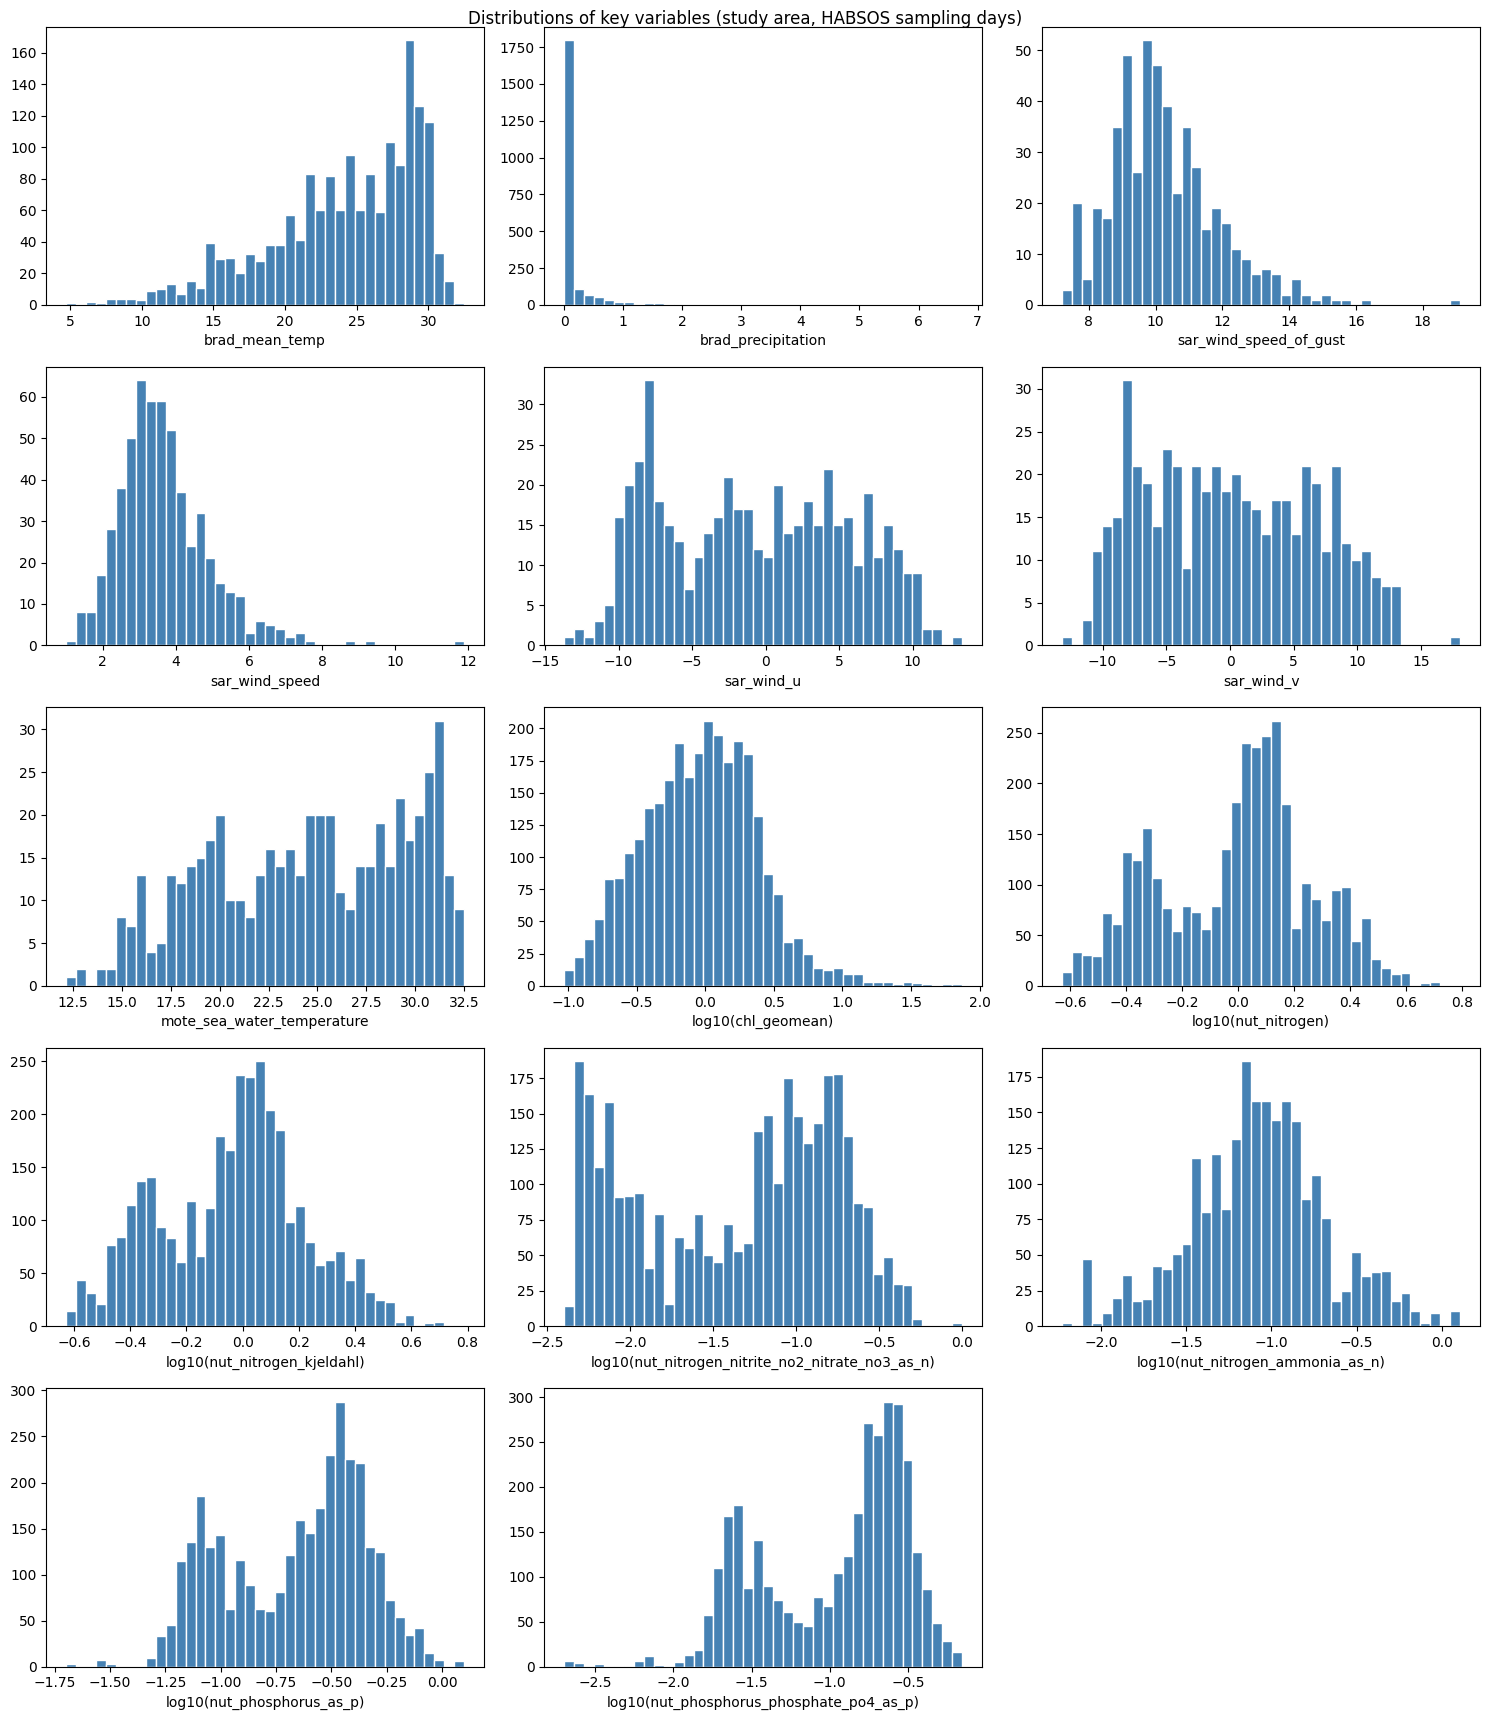

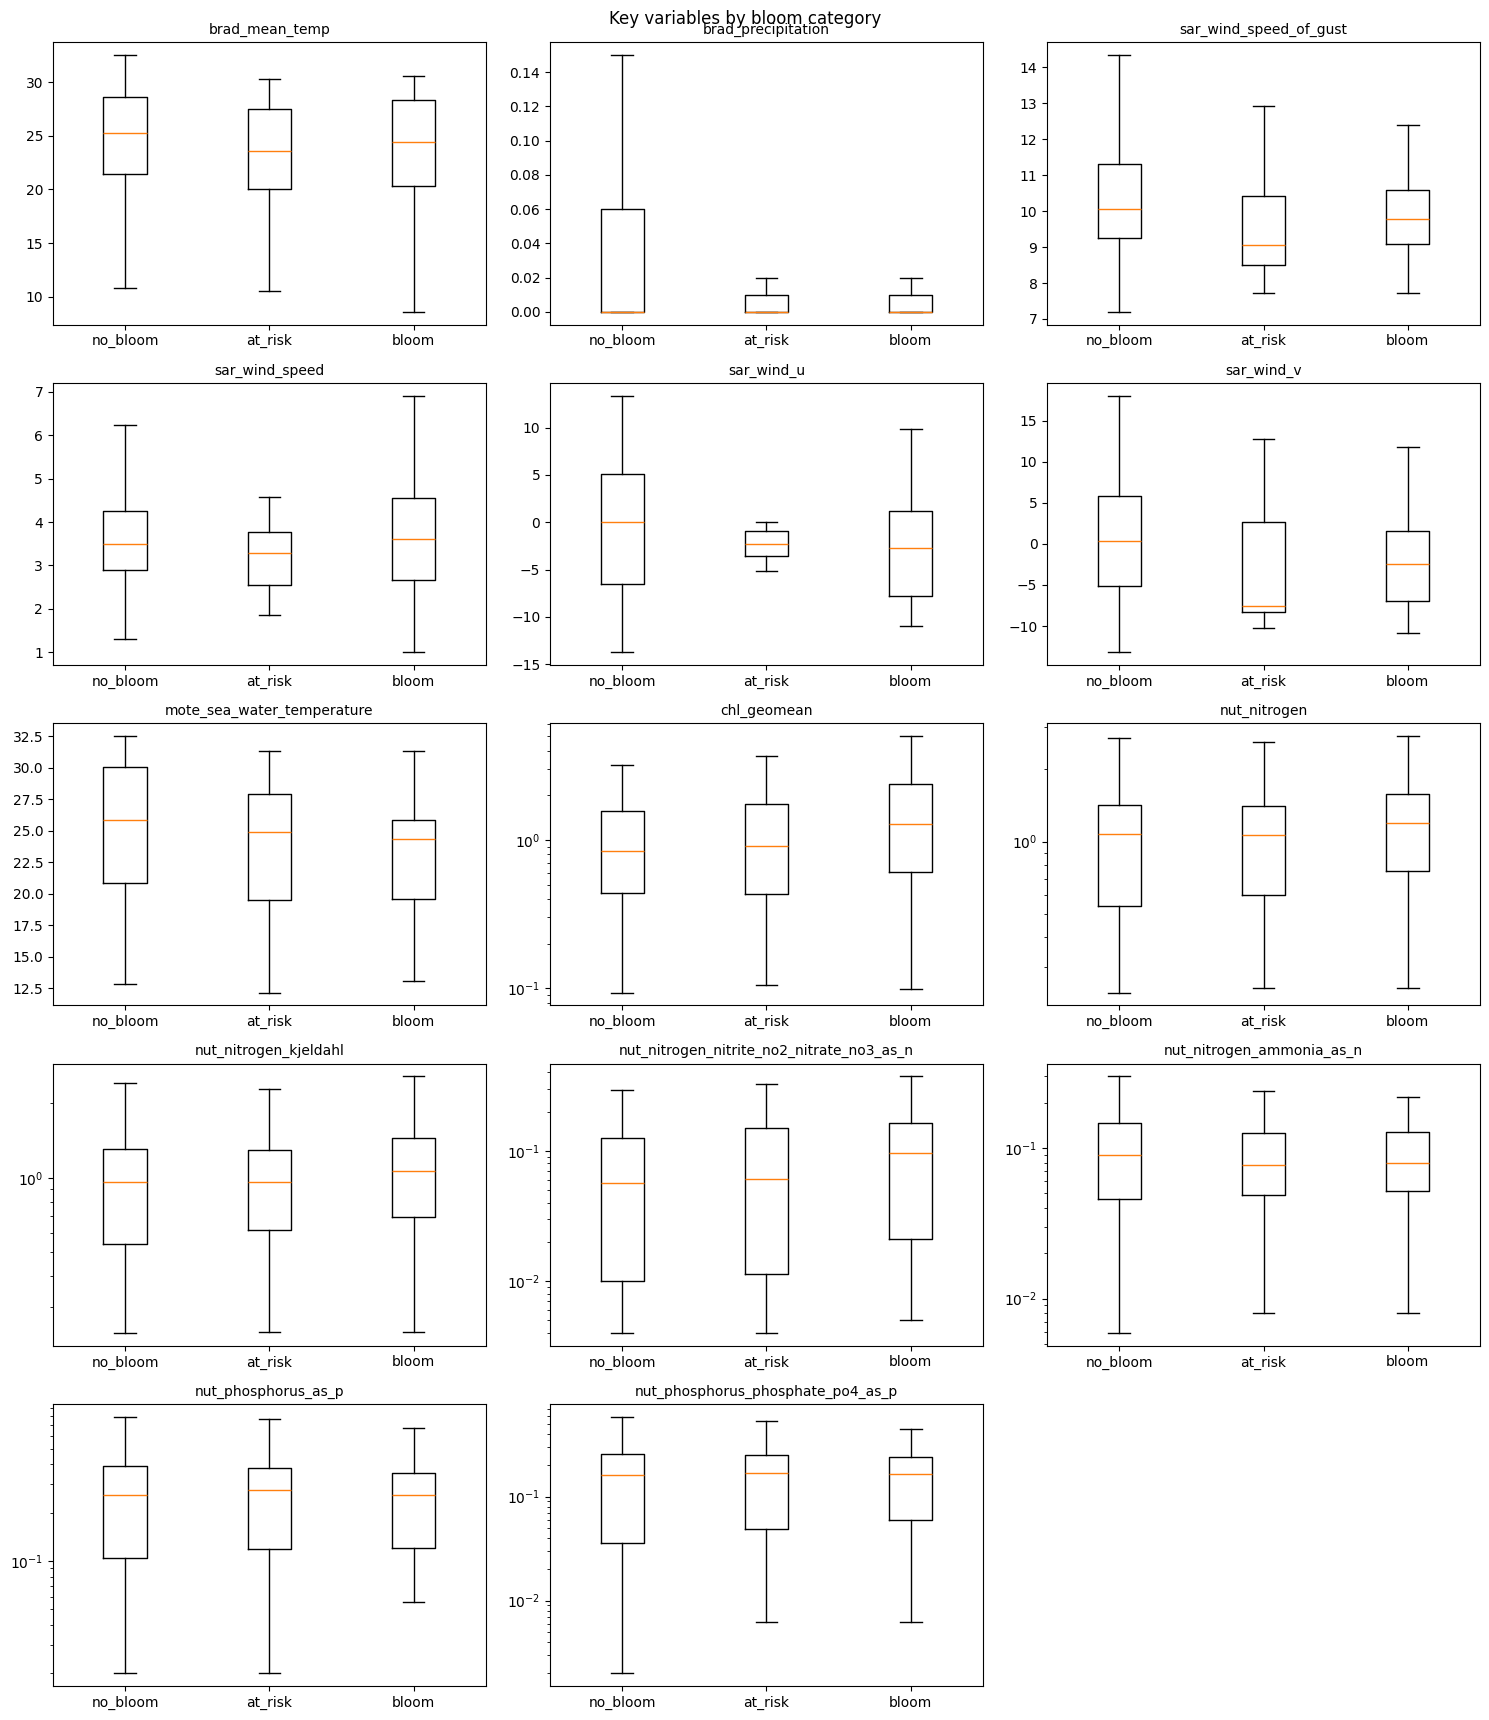

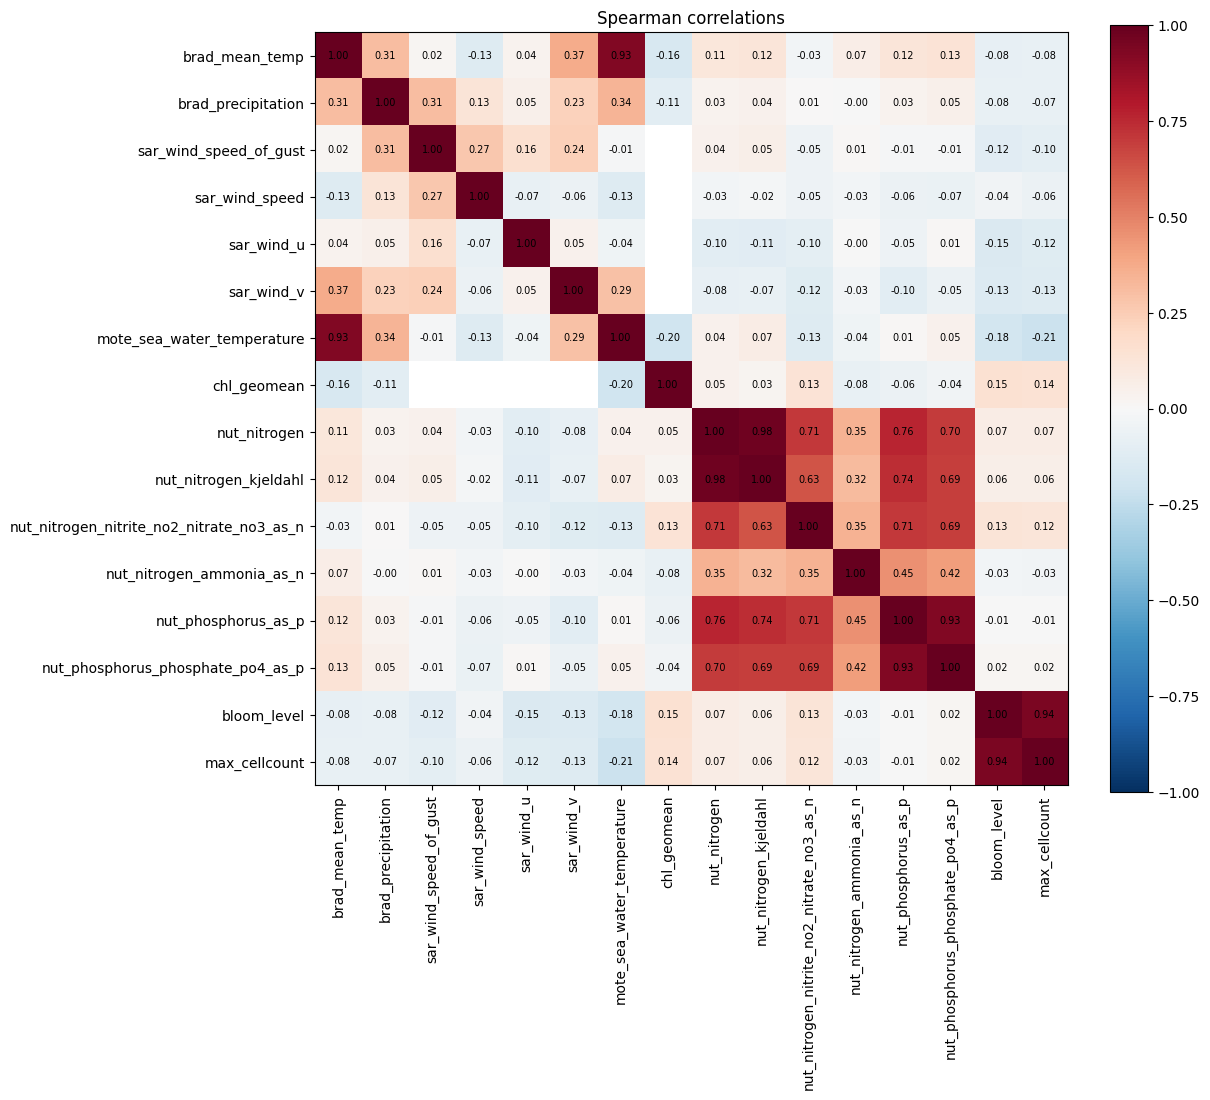

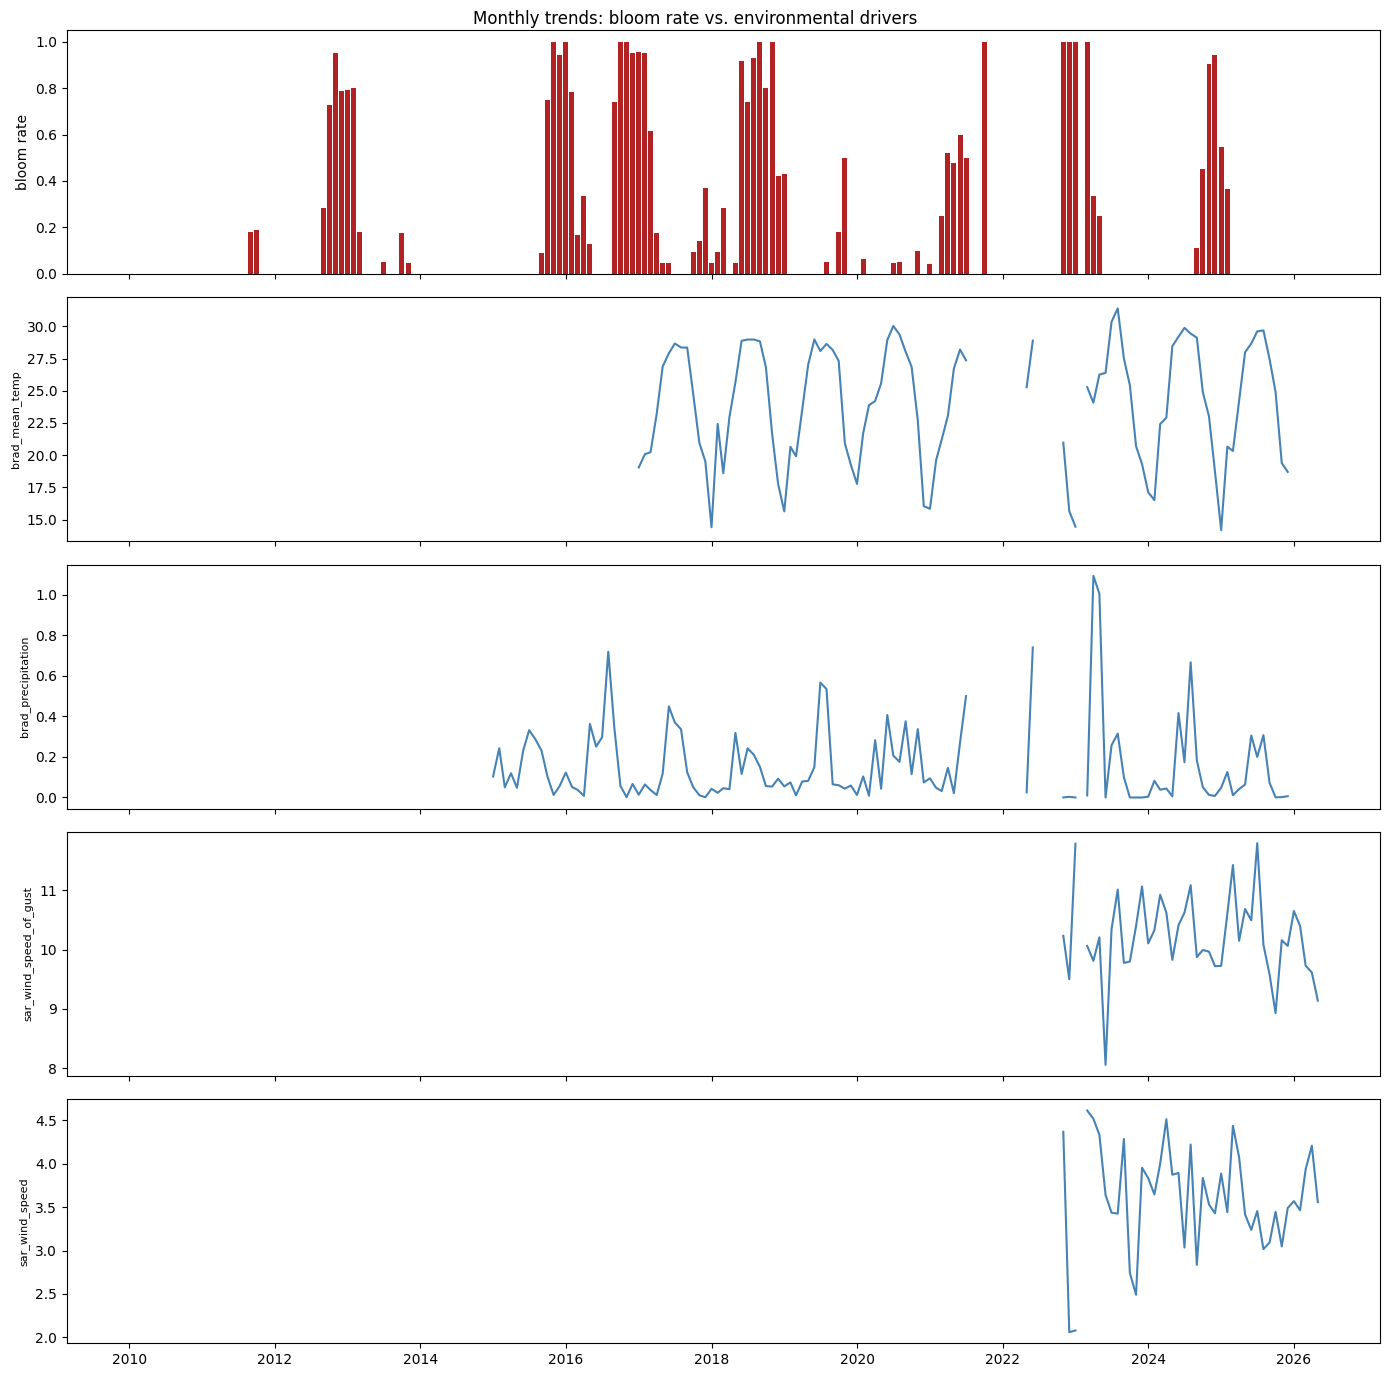

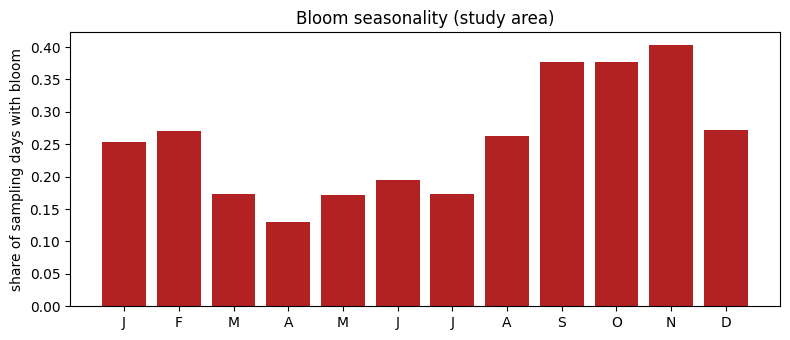


=== Spearman correlation with bloom_level at different lead times ===
                                           lag_0d  lag_7d  lag_14d  lag_30d
mote_sea_water_temperature                 -0.182  -0.180   -0.168   -0.096
chl_geomean                                 0.150   0.151    0.112    0.105
sar_wind_u                                 -0.148  -0.187   -0.244   -0.284
sar_wind_v                                 -0.135  -0.129   -0.094   -0.047
nut_nitrogen_nitrite_no2_nitrate_no3_as_n   0.129   0.161    0.162    0.155
sar_wind_speed_of_gust                     -0.115  -0.123   -0.062   -0.080
brad_mean_temp                             -0.082  -0.058   -0.019    0.017
brad_precipitation                         -0.076  -0.057   -0.011    0.003
nut_nitrogen                                0.075   0.109    0.121    0.106
nut_nitrogen_kjeldahl                       0.057   0.095    0.110    0.085
sar_wind_speed                             -0.035  -0.046    0.011    0.018
nut_nitrogen_ammo

In [ ]:
# TASK 8: Exploratory data analysis (EDA) & summary statistics
# Distributions, correlations, and time trends for chlorophyll-a, nutrients, temp, and wind vs. bloom occurrence

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 8a. Daily bloom target from HABSOS (study area only) ---
label_map = {'no_bloom': 0, 'at_risk': 1, 'bloom': 2}
df_hab = standardized_dfs['habsos'].copy()
df_hab['date'] = pd.to_datetime(df_hab['date'], errors='coerce').astype('datetime64[ns]')
df_hab = df_hab[in_bbox(df_hab)].dropna(subset=['date'])
df_hab['bloom_level'] = df_hab['bloom_label'].map(label_map)

hab_daily = df_hab.groupby('date').agg(
    bloom_level=('bloom_level', 'max'),          # worst condition observed that day
    max_cellcount=('CELLCOUNT', 'max'),
    n_samples=('bloom_level', 'size'))
hab_daily['bloom_flag'] = (hab_daily['bloom_level'] == 2).astype(int)

print("=== Study-area HABSOS daily class balance ===")
print(hab_daily['bloom_level'].map({v: k for k, v in label_map.items()}).value_counts())

# --- 8b. Nutrients: pivot long-format results to one column per key analyte ---
df_nut = standardized_dfs['nutrients'].copy()
df_nut['date'] = pd.to_datetime(df_nut['date'], errors='coerce').astype('datetime64[ns]')
analyte_col = next((c for c in df_nut.columns if any(k in c.lower() for k in ['analyte', 'characteristic', 'parameter'])), None)
value_col = (next((c for c in df_nut.columns if 'result_value' in c.lower().replace(' ', '_')), None)
             or next((c for c in df_nut.columns if 'result' in c.lower() and pd.api.types.is_numeric_dtype(df_nut[c])), None))

nut_daily = pd.DataFrame()
if analyte_col and value_col:
    df_nut[value_col] = pd.to_numeric(df_nut[value_col], errors='coerce')
    key = df_nut[df_nut[analyte_col].astype(str).str.lower()
                 .str.contains('nitrogen|phosph|nitrate|ammon|silica', na=False)]
    top = key[analyte_col].value_counts().head(6).index
    nut_daily = key[key[analyte_col].isin(top)].pivot_table(
        index='date', columns=analyte_col, values=value_col, aggfunc='mean').sort_index()
    nut_daily.columns = ['nut_' + re.sub(r'[^a-z0-9]+', '_', str(c).lower()).strip('_') for c in nut_daily.columns]
    print("\nNutrient analytes used:", list(nut_daily.columns))
else:
    print("\n⚠️ Couldn't auto-detect nutrient analyte/value columns:", list(df_nut.columns))

# --- 8c. Daily feature table (weather + chlorophyll + nutrients) on one calendar ---
starts = [df_weather.index.min(), chl_daily.index.min()]
ends = [df_weather.index.max(), chl_daily.index.max()]
cal = pd.date_range(min(starts), max(ends), freq='D')

feat_daily = df_weather.drop(columns=['has_brad', 'has_sar', 'has_mote']).reindex(cal)
feat_daily = feat_daily.join(chl_daily[['chl_geomean', 'chl_max']].reindex(cal, method='nearest', tolerance=tol))
if not nut_daily.empty:
    feat_daily = feat_daily.join(nut_daily.reindex(cal, method='nearest', tolerance=pd.Timedelta(days=15)))
feat_daily.index.name = 'date'

master = hab_daily.join(feat_daily, how='inner')
print(f"\nEDA master table: {master.shape}, {master.index.min().date()} to {master.index.max().date()}")

# Key variables for plots
key_vars = [c for c in master.columns
            if any(k in c for k in ['chl_geomean', 'mean_temp', 'sea_water_temperature',
                                    'wind_speed', 'wind_u', 'wind_v', 'precip', 'nut_'])
            and not c.endswith('_max')]
log_vars = [c for c in key_vars if c.startswith(('chl', 'nut_'))]

print("\n=== Summary statistics ===")
print(master[key_vars + ['max_cellcount']].describe().T.round(3))

# --- 8d. Distributions ---
ncols = 3
nrows = int(np.ceil(len(key_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, key_vars):
    s = master[col].dropna()
    if col in log_vars:
        s = np.log10(s[s > 0])
        ax.set_xlabel(f"log10({col})")
    else:
        ax.set_xlabel(col)
    ax.hist(s, bins=40, color='steelblue', edgecolor='white')
for ax in axes[len(key_vars):]:
    ax.axis('off')
fig.suptitle("Distributions of key variables (study area, HABSOS sampling days)")
plt.tight_layout(); plt.show()

# --- 8e. Key variables by bloom category ---
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, key_vars):
    data = [master.loc[master['bloom_level'] == lvl, col].dropna() for lvl in [0, 1, 2]]
    ax.boxplot(data, showfliers=False)
    ax.set_xticks([1, 2, 3], ['no_bloom', 'at_risk', 'bloom'])
    ax.set_title(col, fontsize=10)
    if col in log_vars:
        ax.set_yscale('log')
for ax in axes[len(key_vars):]:
    ax.axis('off')
fig.suptitle("Key variables by bloom category")
plt.tight_layout(); plt.show()

# --- 8f. Spearman correlation heatmap (robust to skew/outliers) ---
corr_cols = key_vars + ['bloom_level', 'max_cellcount']
corr = master[corr_cols].corr(method='spearman')
size = 1 + 0.7 * len(corr_cols)
fig, ax = plt.subplots(figsize=(size, size))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=90)
ax.set_yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        if pd.notna(corr.iloc[i, j]):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=7)
plt.colorbar(im, fraction=0.046)
ax.set_title("Spearman correlations")
plt.tight_layout(); plt.show()

# --- 8g. Time trends (monthly) ---
monthly = master.resample('MS').mean(numeric_only=True)
trend_vars = [c for c in key_vars if not c.startswith('nut_')][:4]
fig, axes = plt.subplots(len(trend_vars) + 1, 1, figsize=(14, 2.8 * (len(trend_vars) + 1)), sharex=True)
axes[0].bar(monthly.index, monthly['bloom_flag'], width=25, color='firebrick')
axes[0].set_ylabel('bloom rate')
for ax, col in zip(axes[1:], trend_vars):
    ax.plot(monthly.index, monthly[col], color='steelblue')
    ax.set_ylabel(col, fontsize=8)
fig.suptitle("Monthly trends: bloom rate vs. environmental drivers")
plt.tight_layout(); plt.show()

# Seasonality (uses all study-area HABSOS days, not just the weather overlap)
seasonal = hab_daily.groupby(hab_daily.index.month)['bloom_flag'].mean()
plt.figure(figsize=(8, 3.5))
plt.bar(seasonal.index, seasonal.values, color='firebrick')
plt.xticks(range(1, 13), ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
plt.ylabel('share of sampling days with bloom')
plt.title('Bloom seasonality (study area)')
plt.tight_layout(); plt.show()

# --- 8h. Lagged correlations: do conditions N days earlier relate to bloom level? (forecasting signal) ---
lags = [0, 7, 14, 30]
lag_vars = [c for c in key_vars if c in feat_daily.columns]
rows = []
for lag in lags:
    shifted = feat_daily[lag_vars].shift(lag)     # value from `lag` days BEFORE the bloom observation
    joined = hab_daily[['bloom_level']].join(shifted, how='inner')
    rows.append(joined.corr(method='spearman')['bloom_level'].drop('bloom_level').rename(f'lag_{lag}d'))
lag_corr = pd.concat(rows, axis=1)

print("\n=== Spearman correlation with bloom_level at different lead times ===")
print(lag_corr.round(3).sort_values('lag_0d', key=abs, ascending=False))

master.to_csv("data/processed/eda_master_daily.csv")
feat_daily.to_csv("data/processed/features_daily.csv")
print("\nSaved EDA master table + daily feature table.")

## Task #6 Documentation: Merging Weather + Water Temp Datasets

* **Time alignment:** All three sources were collapsed to one row per calendar day (UTC date) and joined on a continuous daily index, so missing days show up as explicit NaN rows.
* **Bradenton:** Rebuilt from the raw file. COOP codes were handled ('M' → missing, 'T' trace precip → 0), and temperatures were converted from °F to °C.
* **Sarasota wind:** Wind speed and direction were converted to u/v vector components before daily averaging, because compass directions can't be averaged directly. The daily max wind speed was also kept.
* **Mote bottom temp:** Daily mean and daily max.
* **Gaps:** Only internal gaps of 2 days or less were linearly interpolated; longer gaps stay NaN.
* **Location:** All stations fall inside the Sarasota/Bradenton study area, so the join is by date only.
* **Output:** `data/processed/weather_watertemp_daily.csv`. The `has_brad`, `has_sar`, and `has_mote` flags mark coverage; all three overlap from [fill in date].

## Task #7 Documentation: Chlorophyll Satellite Alignment

* **Spatial subset:** Bounding box 26.9–27.6°N, 82.9–82.3°W. Non-positive and missing pixels were dropped.
* **Temporal alignment:** Each sample is matched to the nearest satellite image within ± half the product's cadence ([fill in] days).
* **Spatial alignment:** Each sample with coordinates is matched to the nearest pixel within about 5 km. The study-area daily geometric mean is also attached, because chlorophyll-a is log-normally distributed.
* **Outputs:** `chlorophyll_studyarea_daily.csv` and `sampling_events_chl_matched.csv` (match rates by dataset are printed in the cell).

## Task #8 EDA Findings (fill in after running)

* **Class balance in study area:**
* **Seasonality:**
* **Strongest correlates of bloom_level:**
* **Lead-time signal (7/14/30-day lags):**
* **Data gaps / caveats:**